# 01 — Training

**Project:** Interior wall defect detection — storm-damaged residential interior, Lisbon
**Dataset:** `interior-wall-defects` v1 — 5 classes, 1280 px, no augmentation at export
**Model:** YOLO11s, transfer learning from COCO-pretrained weights

---

### What this notebook does

1. Downloads the **frozen dataset release** from GitHub — no API key, no account needed.
2. **Verifies the SHA256** so the run is provably against the same bytes every time.
3. Repairs the export's `data.yaml` paths for this runtime.
4. Audits the dataset — per-split image/label counts, per-class instance counts, empty labels.
5. Trains, then evaluates on **validation** and **test** separately.
6. Collects every figure and metric into `evidence/` for the report.

### Reproducibility contract

- No Roboflow API key is used, or needed. Nothing secret is read, printed or committed.
- The dataset is pinned by **release tag + SHA256**, not by "latest version".
- `seed=0`, `deterministic=True`.
- Designed to survive **Runtime → Restart and run all** from a cold Colab runtime.

> Runtime: **GPU** (Runtime → Change runtime type → T4 GPU or better).


---


## **1. Environment**


In [ ]:
import subprocess, sys, platform
from importlib.metadata import version, PackageNotFoundError

# Pinned: the version that produced the reported results. The dataset is pinned by
# SHA256 and the code by git; without this, the thing that turns one into the other
# is whatever Ultralytics ships on the day someone re-runs this.
ULTRALYTICS_VERSION = "8.4.166"

try:
    installed = version("ultralytics")
except PackageNotFoundError:
    installed = None

if installed != ULTRALYTICS_VERSION:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    f"ultralytics=={ULTRALYTICS_VERSION}"], check=True)

import ultralytics, torch
from ultralytics import YOLO

print(f"python       {platform.python_version()}")
print(f"ultralytics  {ultralytics.__version__}")
print(f"torch        {torch.__version__}")
print(f"cuda         {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device       {torch.cuda.get_device_name(0)}")
    print(f"vram         {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("\n!! No GPU. Training at imgsz=1280 on CPU is not viable.")
    print("   Runtime -> Change runtime type -> T4 GPU, then Restart and run all.")

if ultralytics.__version__ != ULTRALYTICS_VERSION:
    print(f"\n!! ultralytics {ultralytics.__version__} is loaded, "
          f"{ULTRALYTICS_VERSION} is pinned.")
    print("   Runtime -> Restart session, then Run all.")

python       3.13.15
ultralytics  8.4.166
torch        2.11.0+cu128
cuda         True
device       Tesla T4
vram         15.6 GB


---


## **2. Configuration**

Every parameter that defines a training run lives in this cell. Nothing below it is edited between runs.

Three configurations are defined in `RUNS`, and `RUN_TAG` selects one. Changing that single string reproduces any run in the ablation — `run3` additionally requires the class-merge cell between sections #5 and #6. The runs are documented under Experimental record in `docs/error_analysis.md`/section 3.

`DATASET_URL` and `DATASET_SHA256` together are the dataset's identity. The URL says *which file*; the hash says *which state of that file*. Change the dataset and both must change, which is the point — you cannot silently retrain on different data.


In [ ]:
from pathlib import Path

# --- dataset (frozen GitHub release asset; public, no key) ---------------------
DATASET_URL     = "https://github.com/JBA69/interior-wall-defects/releases/download/v1.0/interior-wall-defects-v1-yolo11.zip"
DATASET_SHA256  = "9137b89d2f406adf1fa7dbfc6bf5a2e95db396d39c26a8c80d248a2f0b8b8a42"
DATASET_VERSION = "v1"

# --- classes, in the export's index order --------------------------------------
# EXPORT_CLASSES is the contract with the released dataset and never changes.
# CLASSES is what the current run trains on (run3's merge cell rewrites it).
EXPORT_CLASSES = ["blistering", "crack", "damp_patch", "mould", "peeling_paint"]
CLASSES        = list(EXPORT_CLASSES)

# --- model ---------------------------------------------------------------------
MODEL_WEIGHTS = "yolo11s.pt"   # s, not n: hairline cracks need the capacity
IMGSZ         = 1280           # justified by docs/capture_resolution_test.md
BATCH         = 8              # drop to 4 if CUDA OOM at 1280
SEED          = 0

# --- the three runs of the ablation (docs/error_analysis.md §3) ----------------
# Geometric augmentation is zero-rotation / no-vertical-flip in all three:
# walls are vertical and rising damp has a top edge.
RUNS = {
    # run 1 — reduced augmentation, justified on resolution grounds. REFUTED.
    "run1": dict(
        epochs=100, patience=20, classes=5,
        aug=dict(mosaic=0.0, scale=0.25, hsv_v=0.2, hsv_s=0.4, hsv_h=0.015,
                 degrees=0.0, flipud=0.0, fliplr=0.5, translate=0.1, erasing=0.0),
    ),
    # run 2 — augmentation restored. REPORTED MODEL.
    "run2": dict(
        epochs=150, patience=40, classes=5,
        aug=dict(mosaic=1.0, close_mosaic=30, scale=0.5, hsv_v=0.3, hsv_s=0.6,
                 hsv_h=0.015, degrees=0.0, flipud=0.0, fliplr=0.5,
                 translate=0.1, erasing=0.0),
    ),
    # run 3 — as run 2, blistering + peeling_paint merged. REJECTED.
    #         ALSO requires the class-merge cell between §5 and §6.
    "run3": dict(
        epochs=150, patience=40, classes=4,
        aug=dict(mosaic=1.0, close_mosaic=30, scale=0.5, hsv_v=0.3, hsv_s=0.6,
                 hsv_h=0.015, degrees=0.0, flipud=0.0, fliplr=0.5,
                 translate=0.1, erasing=0.0),
    ),
}

RUN_TAG = "run2"               # <-- the only line to change to reproduce another run
assert RUN_TAG in RUNS, f"RUN_TAG must be one of {list(RUNS)}"
RUN = RUNS[RUN_TAG]

RUN_NAME = f"wall_defects_{DATASET_VERSION}_yolo11s_{IMGSZ}_{RUN_TAG}"

# --- paths ---------------------------------------------------------------------
ROOT     = Path("/content") if Path("/content").exists() else Path.cwd()
ZIP_PATH = ROOT / "dataset.zip"
DATA_DIR = ROOT / "dataset"
EVIDENCE = ROOT / f"evidence_{RUN_TAG}"
EVIDENCE.mkdir(parents=True, exist_ok=True)

print(f"run       {RUN_TAG}  ({RUN['classes']} classes, "
      f"{RUN['epochs']} epochs, patience {RUN['patience']})")
print(f"aug       {RUN['aug']}")
print(f"root      {ROOT}")
print(f"dataset   {DATA_DIR}")
print(f"evidence  {EVIDENCE}")
print(f"run name  {RUN_NAME}")

run       run2  (5 classes, 150 epochs, patience 40)
aug       {'mosaic': 1.0, 'close_mosaic': 30, 'scale': 0.5, 'hsv_v': 0.3, 'hsv_s': 0.6, 'hsv_h': 0.015, 'degrees': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'translate': 0.1, 'erasing': 0.0}
root      /content
dataset   /content/dataset
evidence  /content/evidence_run2
run name  wall_defects_v1_yolo11s_1280_run2


The printout confirms which configuration is live. Read it before anything else, because
every number produced later belongs to this run and no other.

- **run** — which of the three ablation configurations is selected, with its epoch budget
  and patience. If this says `run1` when you meant `run2`, stop now.
- **aug** — the complete augmentation dictionary passed to the trainer. This is the same
  object recorded into `run_record.json` in #10, so the provenance file cannot disagree
  with what actually ran.
- **root** — the Colab working directory for the session.
- **dataset** — where the verified dataset will be extracted. YOLO reads images and labels
  from here.
- **evidence** — where figures, metrics and weights are collected. Named per run, so one
  run cannot overwrite another's evidence.
- **run name** — the folder name under `runs/`, carrying the dataset version, model, image
  size and run tag.

---


## **3. Download and verify**

The notebook downloads the dataset from a public release asset, so anyone running this notebook gets the same file. No login, no API key, no Roboflow account.

After downloading, it compares the file's SHA-256 hash against the expected one. Different tools print the same hash in different letter cases — PowerShell uppercase, Python lowercase, so the comparison is case-insensitive, to avoid rejecting a correct file over formatting.

If the hashes disagree, the cell raises and training never starts. That is deliberate: a truncated or replaced download would otherwise train silently and produce a metrics table attributable to nothing.

In [ ]:
import hashlib, urllib.request, shutil

def sha256_of(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

if not ZIP_PATH.exists():
    print(f"downloading {DATASET_URL}")
    with urllib.request.urlopen(DATASET_URL) as r, open(ZIP_PATH, "wb") as f:
        shutil.copyfileobj(r, f)
else:
    print("zip already present, skipping download")

size_mb = ZIP_PATH.stat().st_size / 1e6
digest  = sha256_of(ZIP_PATH)

print(f"\nfile      {ZIP_PATH.name}  ({size_mb:.1f} MB)")
print(f"expected  {DATASET_SHA256.lower()}")
print(f"actual    {digest}")

# case-insensitive: hex is hex, whatever tool wrote it
assert digest.lower() == DATASET_SHA256.strip().lower(), (
    "CHECKSUM MISMATCH — the downloaded file is not the released dataset. "
    "Do not train on it. Re-download, or update DATASET_SHA256 if the release was re-cut."
)
print("\nchecksum OK — this is the released dataset")

zip already present, skipping download

file      dataset.zip  (22.4 MB)
expected  9137b89d2f406adf1fa7dbfc6bf5a2e95db396d39c26a8c80d248a2f0b8b8a42
actual    9137b89d2f406adf1fa7dbfc6bf5a2e95db396d39c26a8c80d248a2f0b8b8a42

checksum OK — this is the released dataset


---


## **4. Unpack and locate `data.yaml`**


This step extracts the dataset ZIP into the Colab workspace and locates `data.yaml` inside it.

`data.yaml` is the file YOLO reads to understand the dataset: where the images for each split live, how many classes there are, and what each class id means. Everything downstream depends on it being correct.

The search uses `rglob` rather than a fixed path because Roboflow sometimes nests the export one directory deeper. Locating the file rather than assuming its position is what lets this cell survive a change in the export's packaging.

In [ ]:
import zipfile

if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)
DATA_DIR.mkdir(parents=True)

with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(DATA_DIR)

# Roboflow sometimes nests everything one level down; find data.yaml wherever it is.
candidates = sorted(DATA_DIR.rglob("data.yaml"))
assert candidates, f"no data.yaml found under {DATA_DIR}"
YAML_PATH = candidates[0]
DATA_ROOT = YAML_PATH.parent

print(f"data.yaml  {YAML_PATH}")
print(f"data root  {DATA_ROOT}\n")
for p in sorted(DATA_ROOT.iterdir()):
    print(f"  {'DIR ' if p.is_dir() else 'file'}  {p.name}")

data.yaml  /content/dataset/data.yaml
data root  /content/dataset

  file  README.dataset.txt
  file  README.roboflow.txt
  file  data.yaml
  DIR   test
  DIR   train
  DIR   valid


The listing shows what the release actually contains: `data.yaml`, and the `train`, `valid` and `test` folders, each holding an `images/` and a `labels/` subfolder.

Note the folder is `valid`, not `val` (that is Roboflow's convention), and #5 maps it to the `val` key YOLO expects. The two README files are Roboflow's own export metadata.

---


## **5. Repair the `data.yaml` paths**

Roboflow writes split paths relative to wherever *it* assumed the file would sit
(`../train/images`). On a fresh Colab runtime those resolve to nothing, and YOLO reports an empty dataset rather than an error. This is the most common reason a Roboflow export "works locally but not in Colab".

This cell rewrites them as absolute paths under `/content/dataset`.

It also **asserts** that the exported class list matches `EXPORT_CLASSES` before overwriting anything. That check is not cosmetic: class ids in the label files are positional. If a future export ordered the classes differently, every `class_id` in every `.txt` would silently mean a different class, the model would train on scrambled labels, and the metrics would look merely poor rather than wrong. The assert converts a silent corruption into a stopped run.

The `as exported` / `rewritten` printouts let you confirm the class list by eye as well.

In [ ]:
import yaml

with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

print("as exported:")
for k in ("train", "val", "test", "nc", "names"):
    if k in cfg:
        print(f"  {k}: {cfg[k]}")

# locate the actual split folders on disk
split_dirs = {}
for split, keys in [("train", ["train"]), ("val", ["valid", "val"]), ("test", ["test"])]:
    for k in keys:
        d = DATA_ROOT / k / "images"
        if d.is_dir():
            split_dirs[split] = d
            break

assert "train" in split_dirs and "val" in split_dirs, f"missing splits, found: {split_dirs}"

cfg["path"] = str(DATA_ROOT)
for split, d in split_dirs.items():
    cfg[split] = str(d)

# The export's class order is load-bearing: class ids in the label files are positional.
exported_names = cfg.get("names")
assert exported_names == EXPORT_CLASSES, (
    "CLASS ORDER CHANGED — refusing to continue.\n"
    f"  exported: {exported_names}\n"
    f"  expected: {EXPORT_CLASSES}\n"
    "Every class_id in every label file would now mean a different class."
)

cfg["names"] = CLASSES
cfg["nc"] = len(CLASSES)

with open(YAML_PATH, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print("\nrewritten:")
for k in ("path", "train", "val", "test", "nc", "names"):
    if k in cfg:
        print(f"  {k}: {cfg[k]}")

as exported:
  train: ../train/images
  val: ../valid/images
  test: ../test/images
  nc: 5
  names: ['blistering', 'crack', 'damp_patch', 'mould', 'peeling_paint']

rewritten:
  path: /content/dataset
  train: /content/dataset/train/images
  val: /content/dataset/valid/images
  test: /content/dataset/test/images
  nc: 5
  names: ['blistering', 'crack', 'damp_patch', 'mould', 'peeling_paint']


---


## **6. Dataset audit**

## 6. Dataset audit

A health check on the dataset, run before training rather than after. This table is also the one the README quotes.

It counts images and labelled instances per split, reports how many images carry an empty label file, and lists any image with **no** label file or any malformed label line.

Three things matter:

- **Every image has a label file.** An image with no `.txt` at all is *skipped* by Ultralytics. An image with an *empty* `.txt` is a background negative and is used in training. These are not the same thing, and the difference is invisible in a file listing.
- **Instance counts per class per split.** `crack` and `peeling_paint` are the thin ones, and a class that is thin in *validation* produces a metric that cannot be interpreted.
- **Background frames.** Roughly 48 across the dataset are deliberate hard negatives — the documented confusers from `areas.csv`.

Note what this cell does **not** do: it counts class ids, it does not validate them. An id outside the expected range would simply be absent from the table. The guard against that is the assert in #5, not here.


In [ ]:
import collections
import pandas as pd

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def audit(images_dir):
    images_dir = Path(images_dir)
    labels_dir = images_dir.parent / "labels"
    imgs = sorted(p for p in images_dir.iterdir() if p.suffix.lower() in IMG_EXT)

    counts = collections.Counter()
    empty, missing, malformed = [], [], []

    for img in imgs:
        lab = labels_dir / f"{img.stem}.txt"
        if not lab.exists():
            missing.append(img.name)
            continue
        lines = [l for l in lab.read_text().splitlines() if l.strip()]
        if not lines:
            empty.append(img.name)
            continue
        for l in lines:
            parts = l.split()
            if len(parts) < 5:
                malformed.append((lab.name, l))
                continue
            counts[int(parts[0])] += 1
    return imgs, counts, empty, missing, malformed

rows, issues = [], {}
stems = {}
for split, d in split_dirs.items():
    imgs, counts, empty, missing, malformed = audit(d)
    stems[split] = sorted(p.stem for p in imgs)
    issues[split] = {"missing_label": missing, "malformed": malformed}
    row = {"split": split, "images": len(imgs),
           "background (empty .txt)": len(empty),
           "NO label file": len(missing)}
    for i, name in enumerate(CLASSES):
        row[name] = counts.get(i, 0)
    row["instances"] = sum(counts.values())
    rows.append(row)

audit_df = pd.DataFrame(rows).set_index("split")
display(audit_df)

audit_df.to_csv(EVIDENCE / "dataset_audit.csv")

for split, iss in issues.items():
    if iss["missing_label"]:
        print(f"\n!! {split}: {len(iss['missing_label'])} images with NO label file "
              f"(these are SKIPPED by training, not treated as background):")
        for n in iss["missing_label"][:10]:
            print(f"     {n}")
    if iss["malformed"]:
        print(f"\n!! {split}: {len(iss['malformed'])} malformed label lines")
        for n, l in iss["malformed"][:5]:
            print(f"     {n}: {l!r}")

if not any(i["missing_label"] or i["malformed"] for i in issues.values()):
    print("\nno structural problems found")

,images,background (empty .txt),NO label file,blistering,crack,damp_patch,mould,peeling_paint,instances
split,,,,,,,,,
train,134,20,0,348,77,290,629,86,1430
val,44,3,0,116,46,101,93,7,363
test,46,23,0,12,25,12,17,7,73



no structural problems found


**Reading the table**

- **images** — frames in each split.
- **background (empty .txt)** — frames with an annotation file containing no boxes. Valid and valuable: these teach the model what is *not* a defect.
- **NO label file** — frames Ultralytics would skip entirely. Zero across all splits, so nothing is being silently dropped.
- **per-class columns** — labelled *instances*, not frames. One frame may carry several boxes.
- **instances** — total boxes in the split.

**What is sound.** Every image has a label file, no label line is malformed, and the training split is dense: 1,430 instances across 134 images, about 10.7 boxes per image. This is not a small-data problem in the naive sense.

**What is not sound, and matters more.**

1. **The test split is not a usable evaluation set.** 46 images, 23 of them background (50%), **73 instances in total** across five classes — fewer than `crack` alone has in validation. `damp_patch` has 12; `peeling_paint` has 7. A per-class mAP computed on 7 instances is not a weak measurement, it is not a measurement. Validation is therefore reported as primary and the test table is published with this stated.

2. **The training domain is a single room.** Splits were assigned by room — train = closet, val = kitchen + hallway, test = living room + office + bedroom — to eliminate the leakage a random split causes on a single-building dataset. The consequence is that 100% of training instances come from one small enclosed space, and evaluation happens on rooms the model has never seen. This is a domain-shift test, not a generalisation test.

3. **The class mix differs between splits.** `mould` is over-represented in train (6.8 : 1 vs an overall 3.9 : 1); `crack` is over-represented in validation (1.7 : 1). The closet has mould and blistering; the kitchen and hallway have cracks. The model is trained on one defect profile and evaluated on another.

None of this is a processing error — it follows from a room-level split that was the right call about leakage. It is the largest single cause of the false-negative rate reported later, and it is the first of the three data improvements in `docs/error_analysis.md`/ section #6.

### **6b. Cross-check the export against the capture log *(optional)***

`areas.csv` is the per-frame log built during capture — 244 rows, room-by-room, with the
intended split for every frame. The export is what actually reached Roboflow. Three train
images are known to have gone astray during annotation; this cell names them.

Upload `areas.csv` to the runtime to run it. Skipped silently if absent, so *Run all* never
breaks on it.


In [ ]:
areas_path = ROOT / "areas.csv"

if not areas_path.exists():
    print("areas.csv not present — skipping cross-check (this is not an error)")
else:
    log = pd.read_csv(areas_path, sep=";", dtype=str).fillna("")
    log.columns = [c.strip() for c in log.columns]
    log = log[log["exclude"].str.strip().str.lower() != "yes"]

    split_map = {"train": "train", "val": "val", "valid": "val", "test": "test"}
    log["split_n"] = log["split"].str.strip().str.lower().map(split_map)
    expected = {s: set(g["photo_id"].str.strip()) for s, g in log.groupby("split_n") if s}

    print(f"{'split':<8}{'logged':>8}{'exported':>10}{'in log not exported':>22}{'exported not in log':>22}")
    lost = {}
    for s in ["train", "val", "test"]:
        exp  = expected.get(s, set())
        got  = set(stems.get(s, []))
        miss = sorted(exp - got)
        extra = sorted(got - exp)
        lost[s] = miss
        print(f"{s:<8}{len(exp):>8}{len(got):>10}{len(miss):>22}{len(extra):>22}")

    for s, miss in lost.items():
        if miss:
            print(f"\n{s} — logged but not in the export ({len(miss)}):")
            for m in miss:
                print(f"   {m}")
            print("   -> add exclude=yes + exclude_reason to these rows in areas.csv,")
            print("      so the log and the release describe the same dataset.")

areas.csv not present — skipping cross-check (this is not an error)


---


## **7. Train**

### Augmentation policy

The configuration used in run 2 stays close to the Ultralytics defaults.
It only changes a few settings, and the choices it doesn’t change are just as deliberate as the ones it does.

#### Adjusted settings

| Setting | Default | Here | Reason |
| --- | --- | --- | --- |
| ``close_mosaic`` | ``10`` | ``30`` | Mosaic combines four images into one ``1280×1280`` canvas, meaning each original image trains at an **effective ~640 px**. Earlier resolution tests showed that hairline cracks disappear at 640 px. Extending the mosaic‑free period aims to give regularisation early and preserve fine detail later. **Note: this setting did not actually take effect in run 2.** |
| ``hsv_v`` | ``0.4`` | ``0.3`` | For ``damp_patch`` and ``mould``, tone is the key visual cue. Strong brightness jitter removes the very signal the model needs, and the dataset already includes real lighting variation. |
| ``hsv_s`` | ``0.7`` | ``0.6`` | Same reasoning: damp often appears as a subtle colour shift, so overly strong saturation jitter would distort it. |

#### Defaults kept intentionally

These settings were reviewed and left unchanged because the defaults are correct for this dataset:

| Setting | Value | Why the default is appropriate |
| --- | --- | --- |
| ``degrees`` | ``0.0`` | Walls are vertical, and rising damp has a real “top edge”. Rotation would break a genuine geometric prior. |
| ``flipud`` | ``0.0`` | Same logic — “up” is meaningful in this dataset. |
| ``fliplr`` | ``0.5`` | Left/right has no semantic meaning on a wall, so horizontal flips are safe. |
| ``mosaic`` | ``1.0`` | See below. |
| ``scale`` | ``0.5`` | See below. |

### Why `mosaic` and `scale` are at default, and not where they started

In **run 1**, `mosaic=0.0` and `scale=0.25` were chosen for a good reason: mosaic reduces effective resolution, and earlier tests showed that hairline cracks disappear at 640 px.
That part was correct — mosaic does shrink the fine detail.

What turned out to be wrong was the assumption about **which effect dominates**.
The experiment showed that the **regularisation mosaic provides matters more** than the **resolution it takes away**.
On a dataset with only 134 training images from a single room, preventing overfitting has a larger impact on performance than preserving full pixel fidelity.

Restoring both settings in **run 2** improved performance across **every class**:

- **mAP50: +32% overall**  
- **Crack detection: +40% (mAP50‑95 +98%)**

The regularisation provided by mosaic is more valuable, on a dataset of only 134 training images from a single room, than the resolution it sacrifices.

The loss curves confirm this:  
the point where `val/box_loss` and `val/dfl_loss` begin to rise (a sign of overfitting) moves from **≈32 epochs in run 1** to **≈50 epochs in run 2**.

This correction is recorded explicitly because the original reasoning was written down before the run — and the run disagreed with it.  
Full comparison: `docs/error_analysis.md` §4.1–4.2.

> **Known limitation.** With `epochs=150`, setting `close_mosaic=30` means mosaic is scheduled to switch off at **epoch 120**.  
> In practice, neither **run 2** nor **run 3** ever reached that point: run 2 stopped at ≈112 epochs and run 3 at ≈100 under `patience=40`.  
> This means the model never entered the intended “fine‑detail finishing phase” where mosaic is disabled and training proceeds on full‑resolution single images.  
> In both runs, **mosaic remained active for the entire duration of training**, so every reported metric comes from a model trained exclusively under mosaic.  
> As a result, the effect of *closing* mosaic — the part designed to recover crack‑level fidelity late in training — remains completely untested.  
> This is the cleanest remaining lever for v3: adjust `close_mosaic` so that mosaic actually turns off *before* early stopping, and compare the curves.


**IMPORTANT NOTE**

> **If this cell dies with `CUDA out of memory`:** set `BATCH = 4` in the config cell and
> re-run from there. Do not reduce `IMGSZ` — that invalidates the resolution argument and
> silently changes what the model can detect.


In [ ]:
# --- run 2: augmentation restored (pre-registered experiment) ---
RUN_NAME = f"wall_defects_{DATASET_VERSION}_yolo11s_{IMGSZ}_mosaic"
EVIDENCE = ROOT / "evidence_run2"
EVIDENCE.mkdir(parents=True, exist_ok=True)

model = YOLO(MODEL_WEIGHTS)

results = model.train(
    data=str(YAML_PATH),
    imgsz=IMGSZ,
    batch=BATCH,
    seed=SEED,
    deterministic=True,
    epochs=RUN["epochs"],
    patience=RUN["patience"],
    name=RUN_NAME,
    project=str(ROOT / "runs"),
    exist_ok=True,
    plots=True,
    val=True,
    **RUN["aug"],
)

SAVE_DIR = Path(getattr(results, "save_dir", None) or model.trainer.save_dir)
BEST     = SAVE_DIR / "weights" / "best.pt"
print(f"\nrun   {RUN_TAG}")
print(f"dir   {SAVE_DIR}")
print(f"best  {BEST}")

New https://pypi.org/project/ultralytics/8.4.167 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=30, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.6, hsv_v=0.3, imgsz=1280, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.

This run restored Ultralytics’ regularisation settings (`mosaic=1.0`, `scale=0.5`) and extended the planned mosaic‑off phase (`close_mosaic=30`).  
Because early stopping fired at ≈112 epochs (`patience=40`), the scheduled mosaic‑off point at epoch 120 was never reached.  
The model therefore trained **entirely under mosaic**, and all reported metrics reflect that regime.  
The late full‑resolution phase remains untested and is the clearest lever for the next experiment.


---


## **8. Training curves and confusion matrix**



=== results.png ===


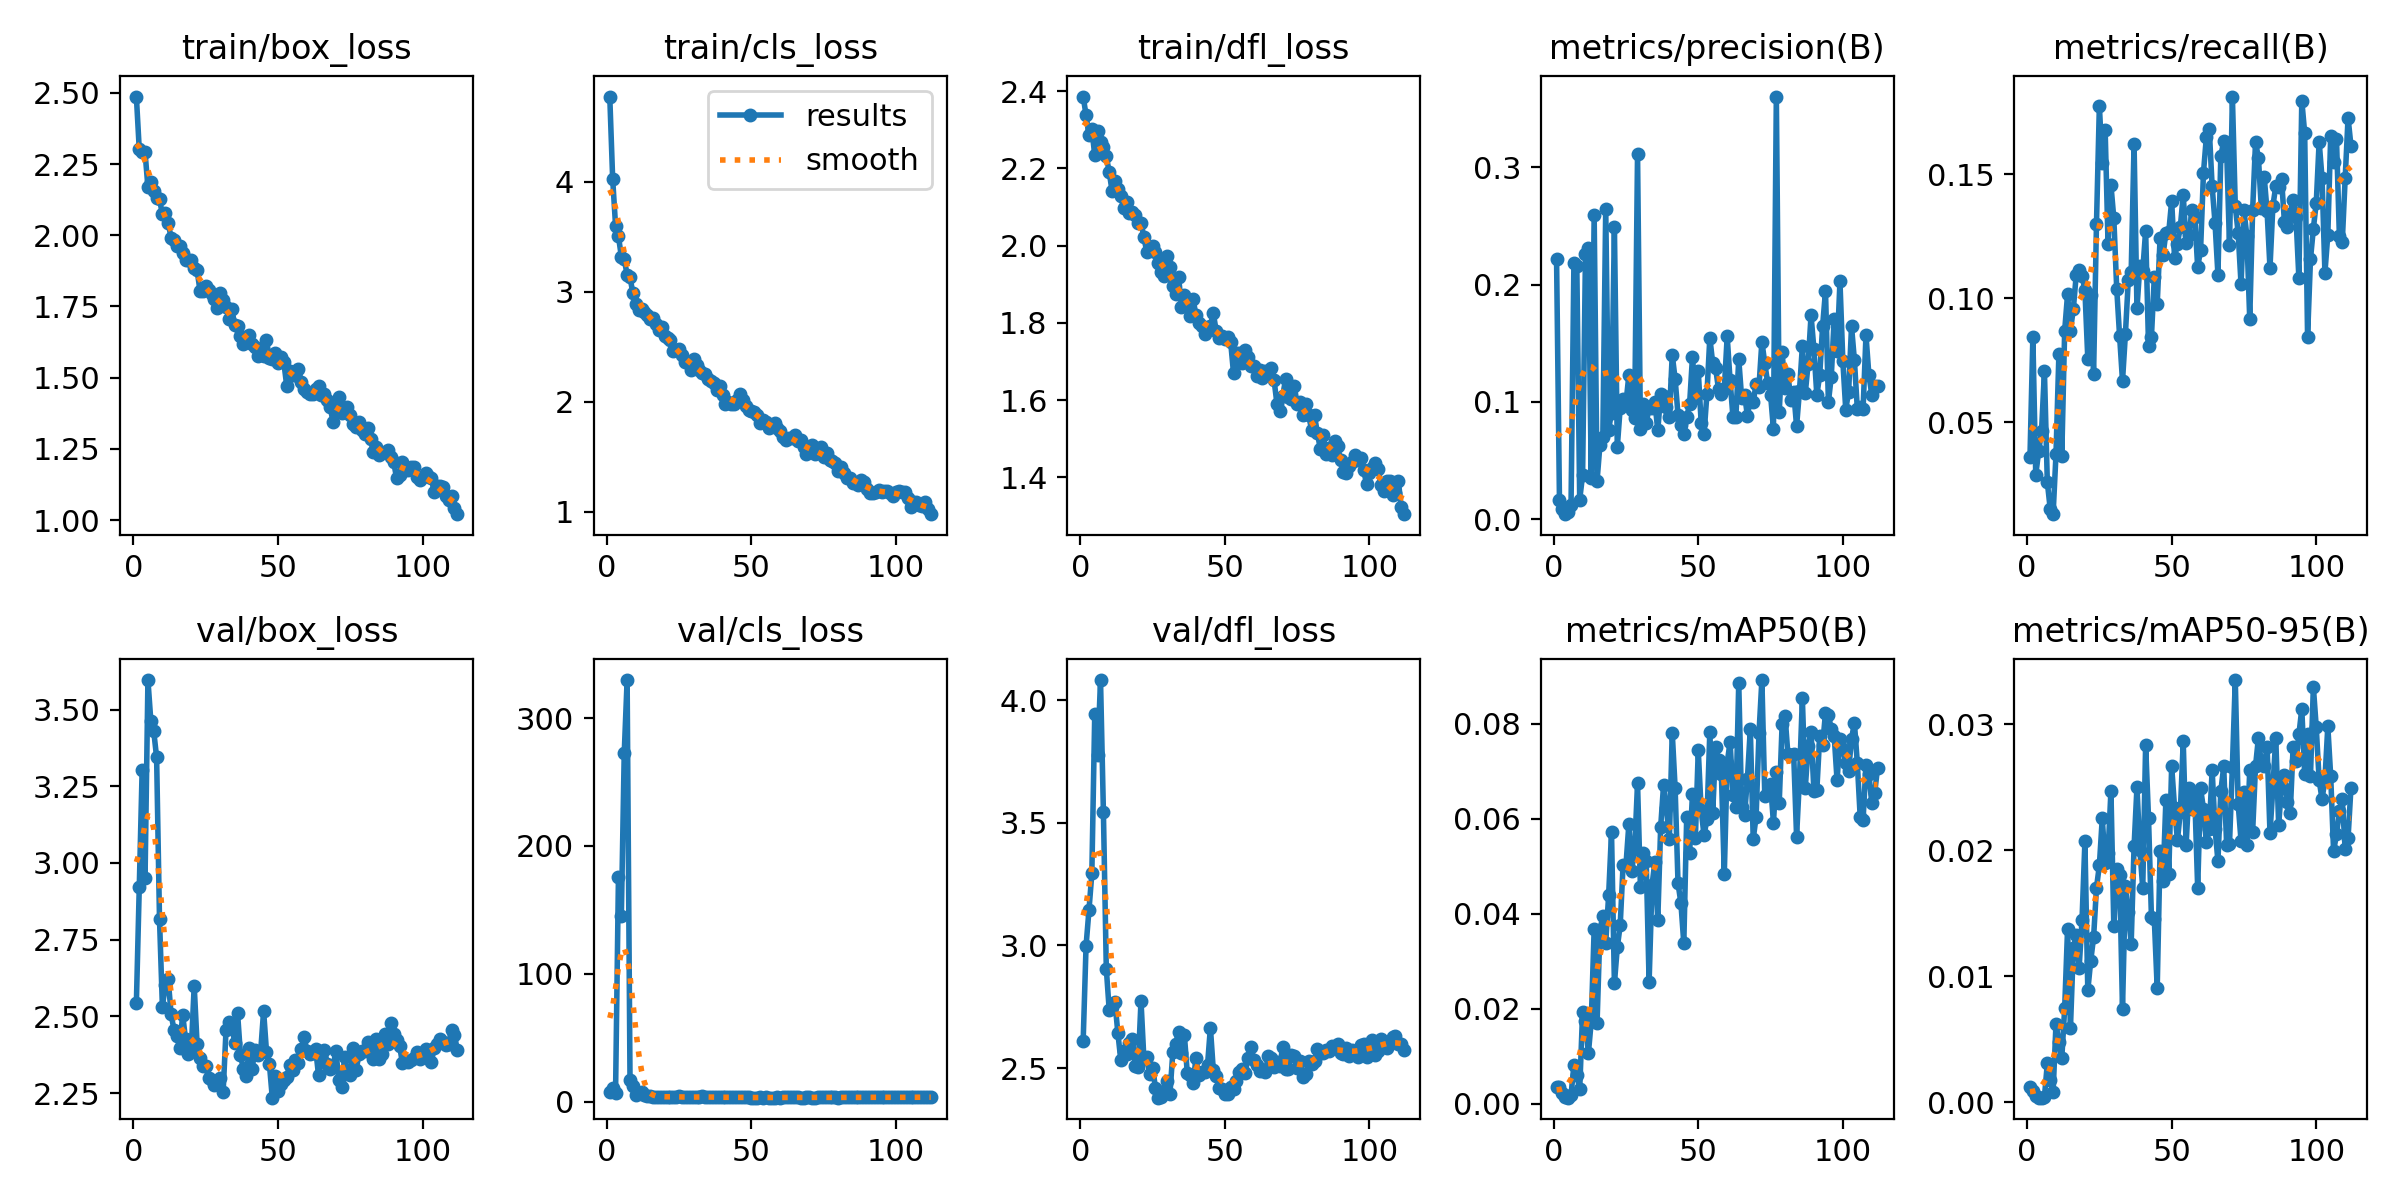


=== confusion_matrix_normalized.png ===


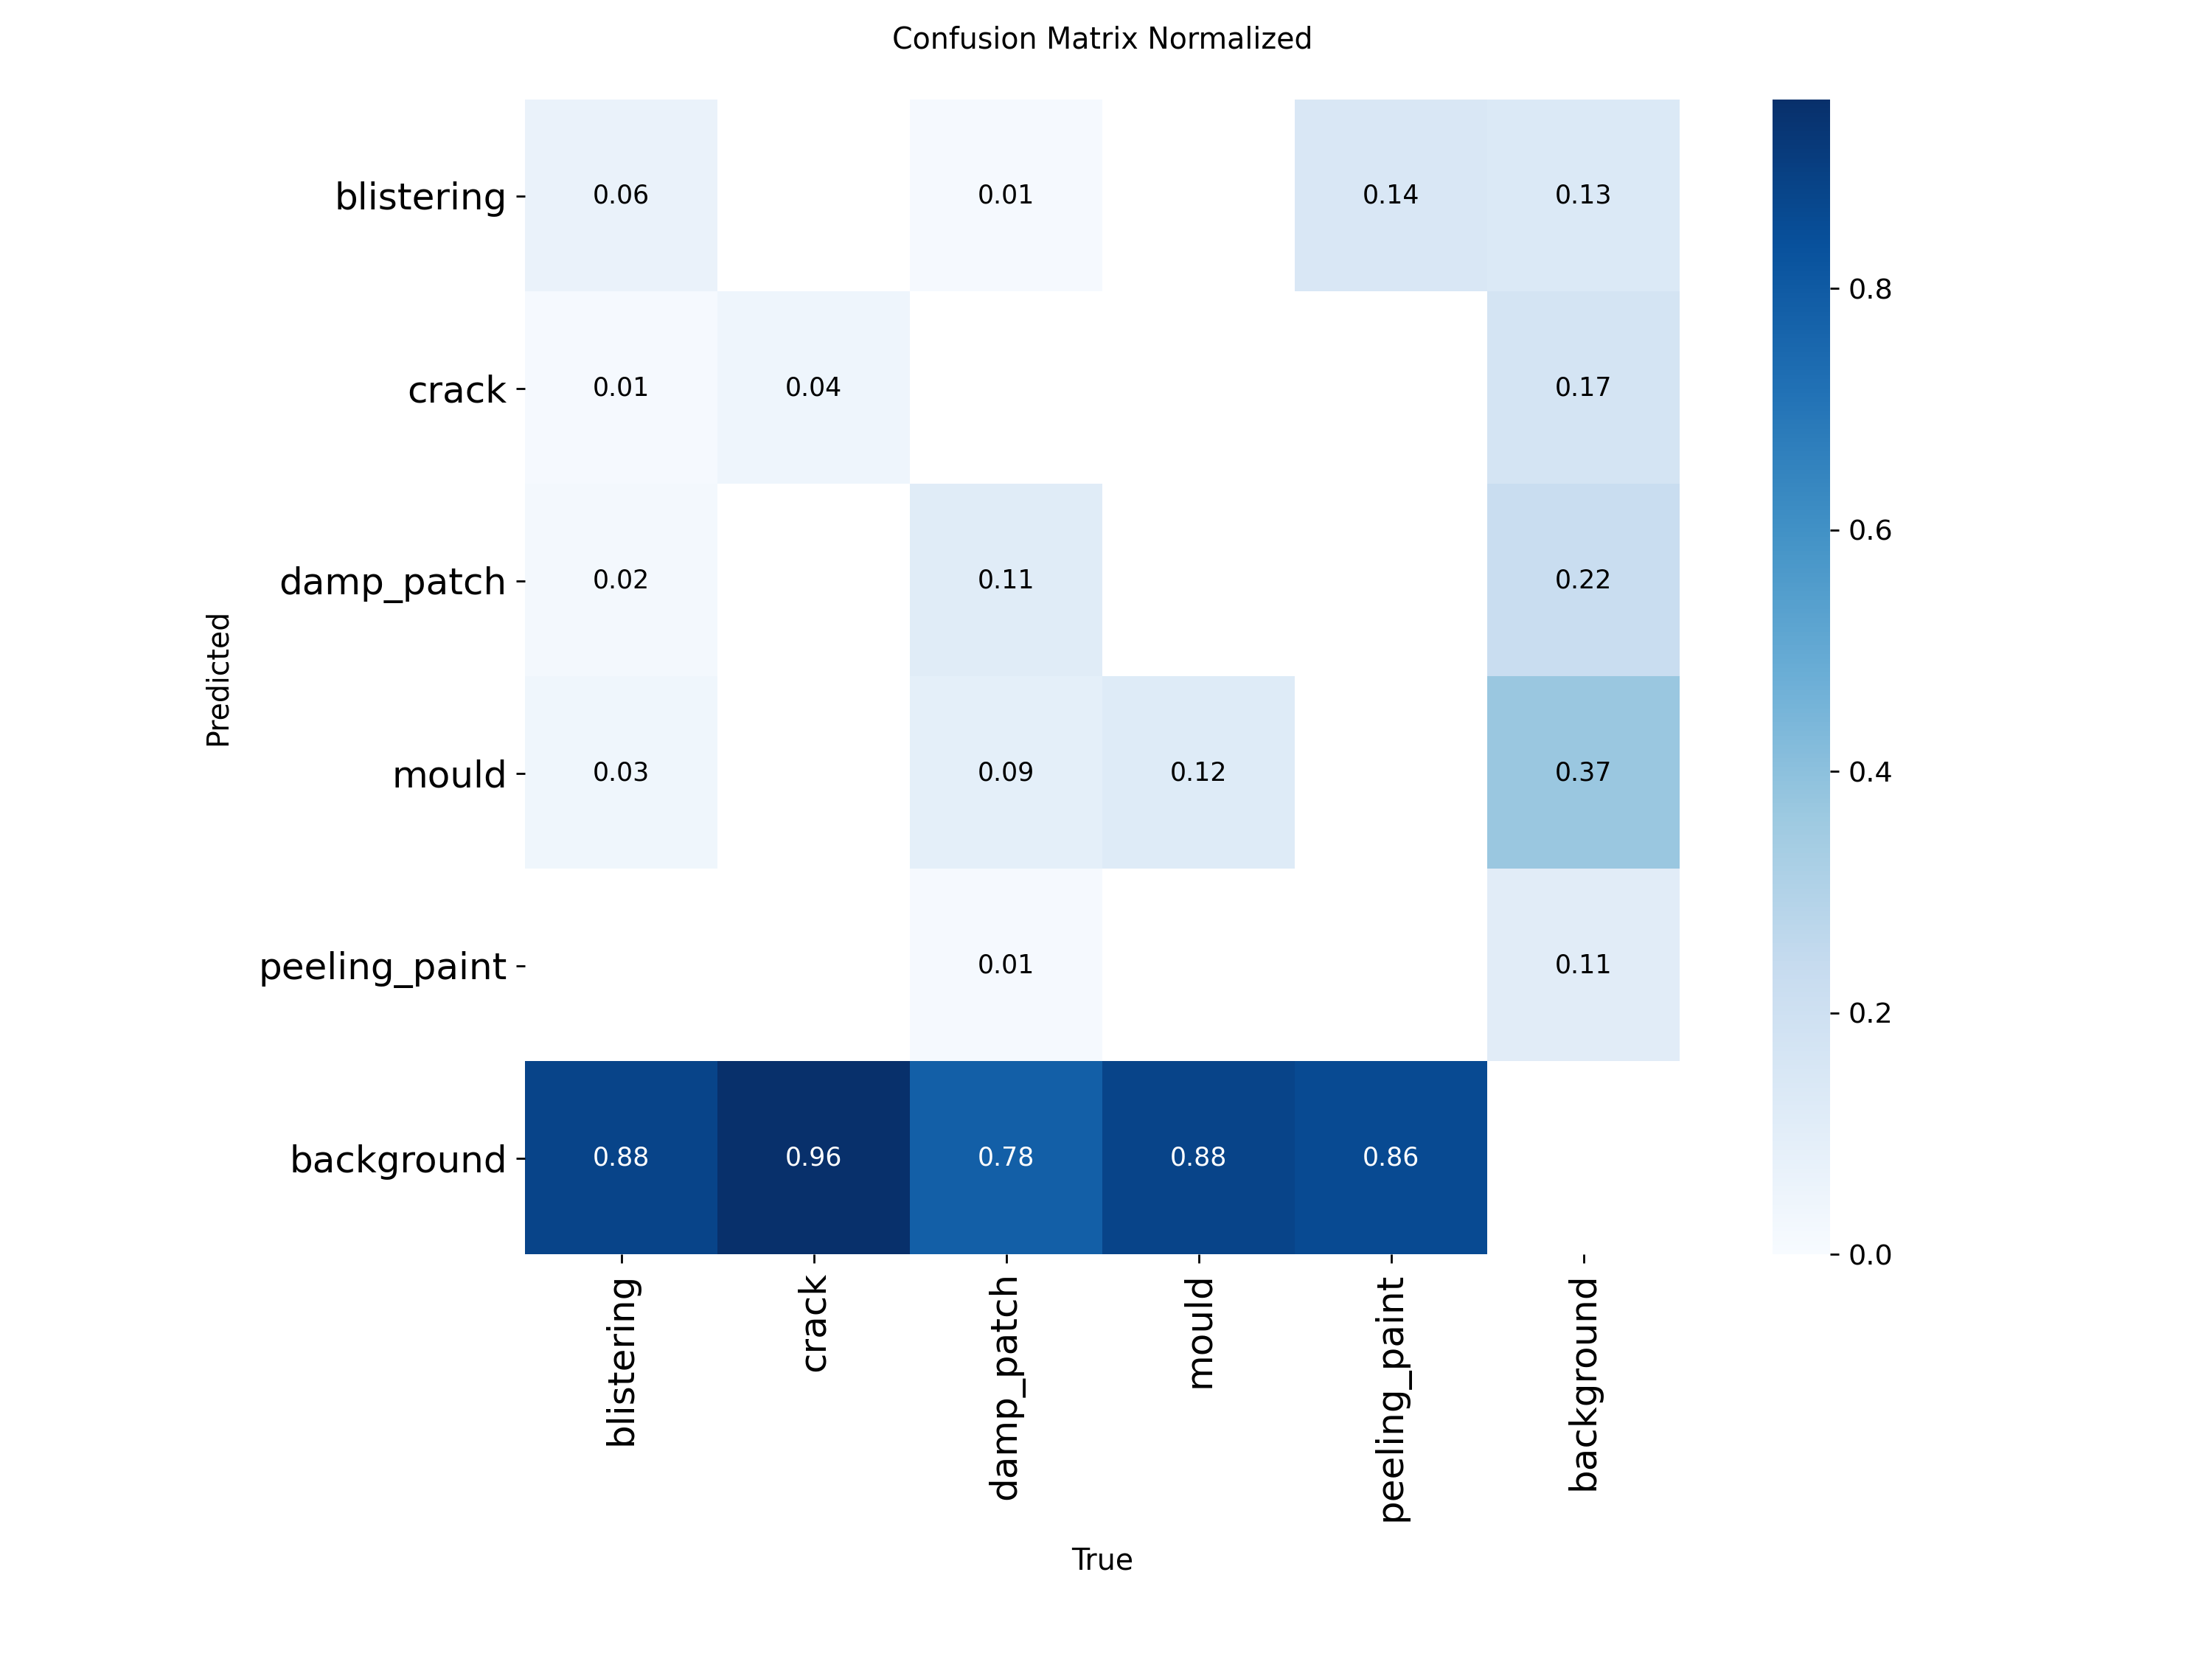


=== confusion_matrix.png ===


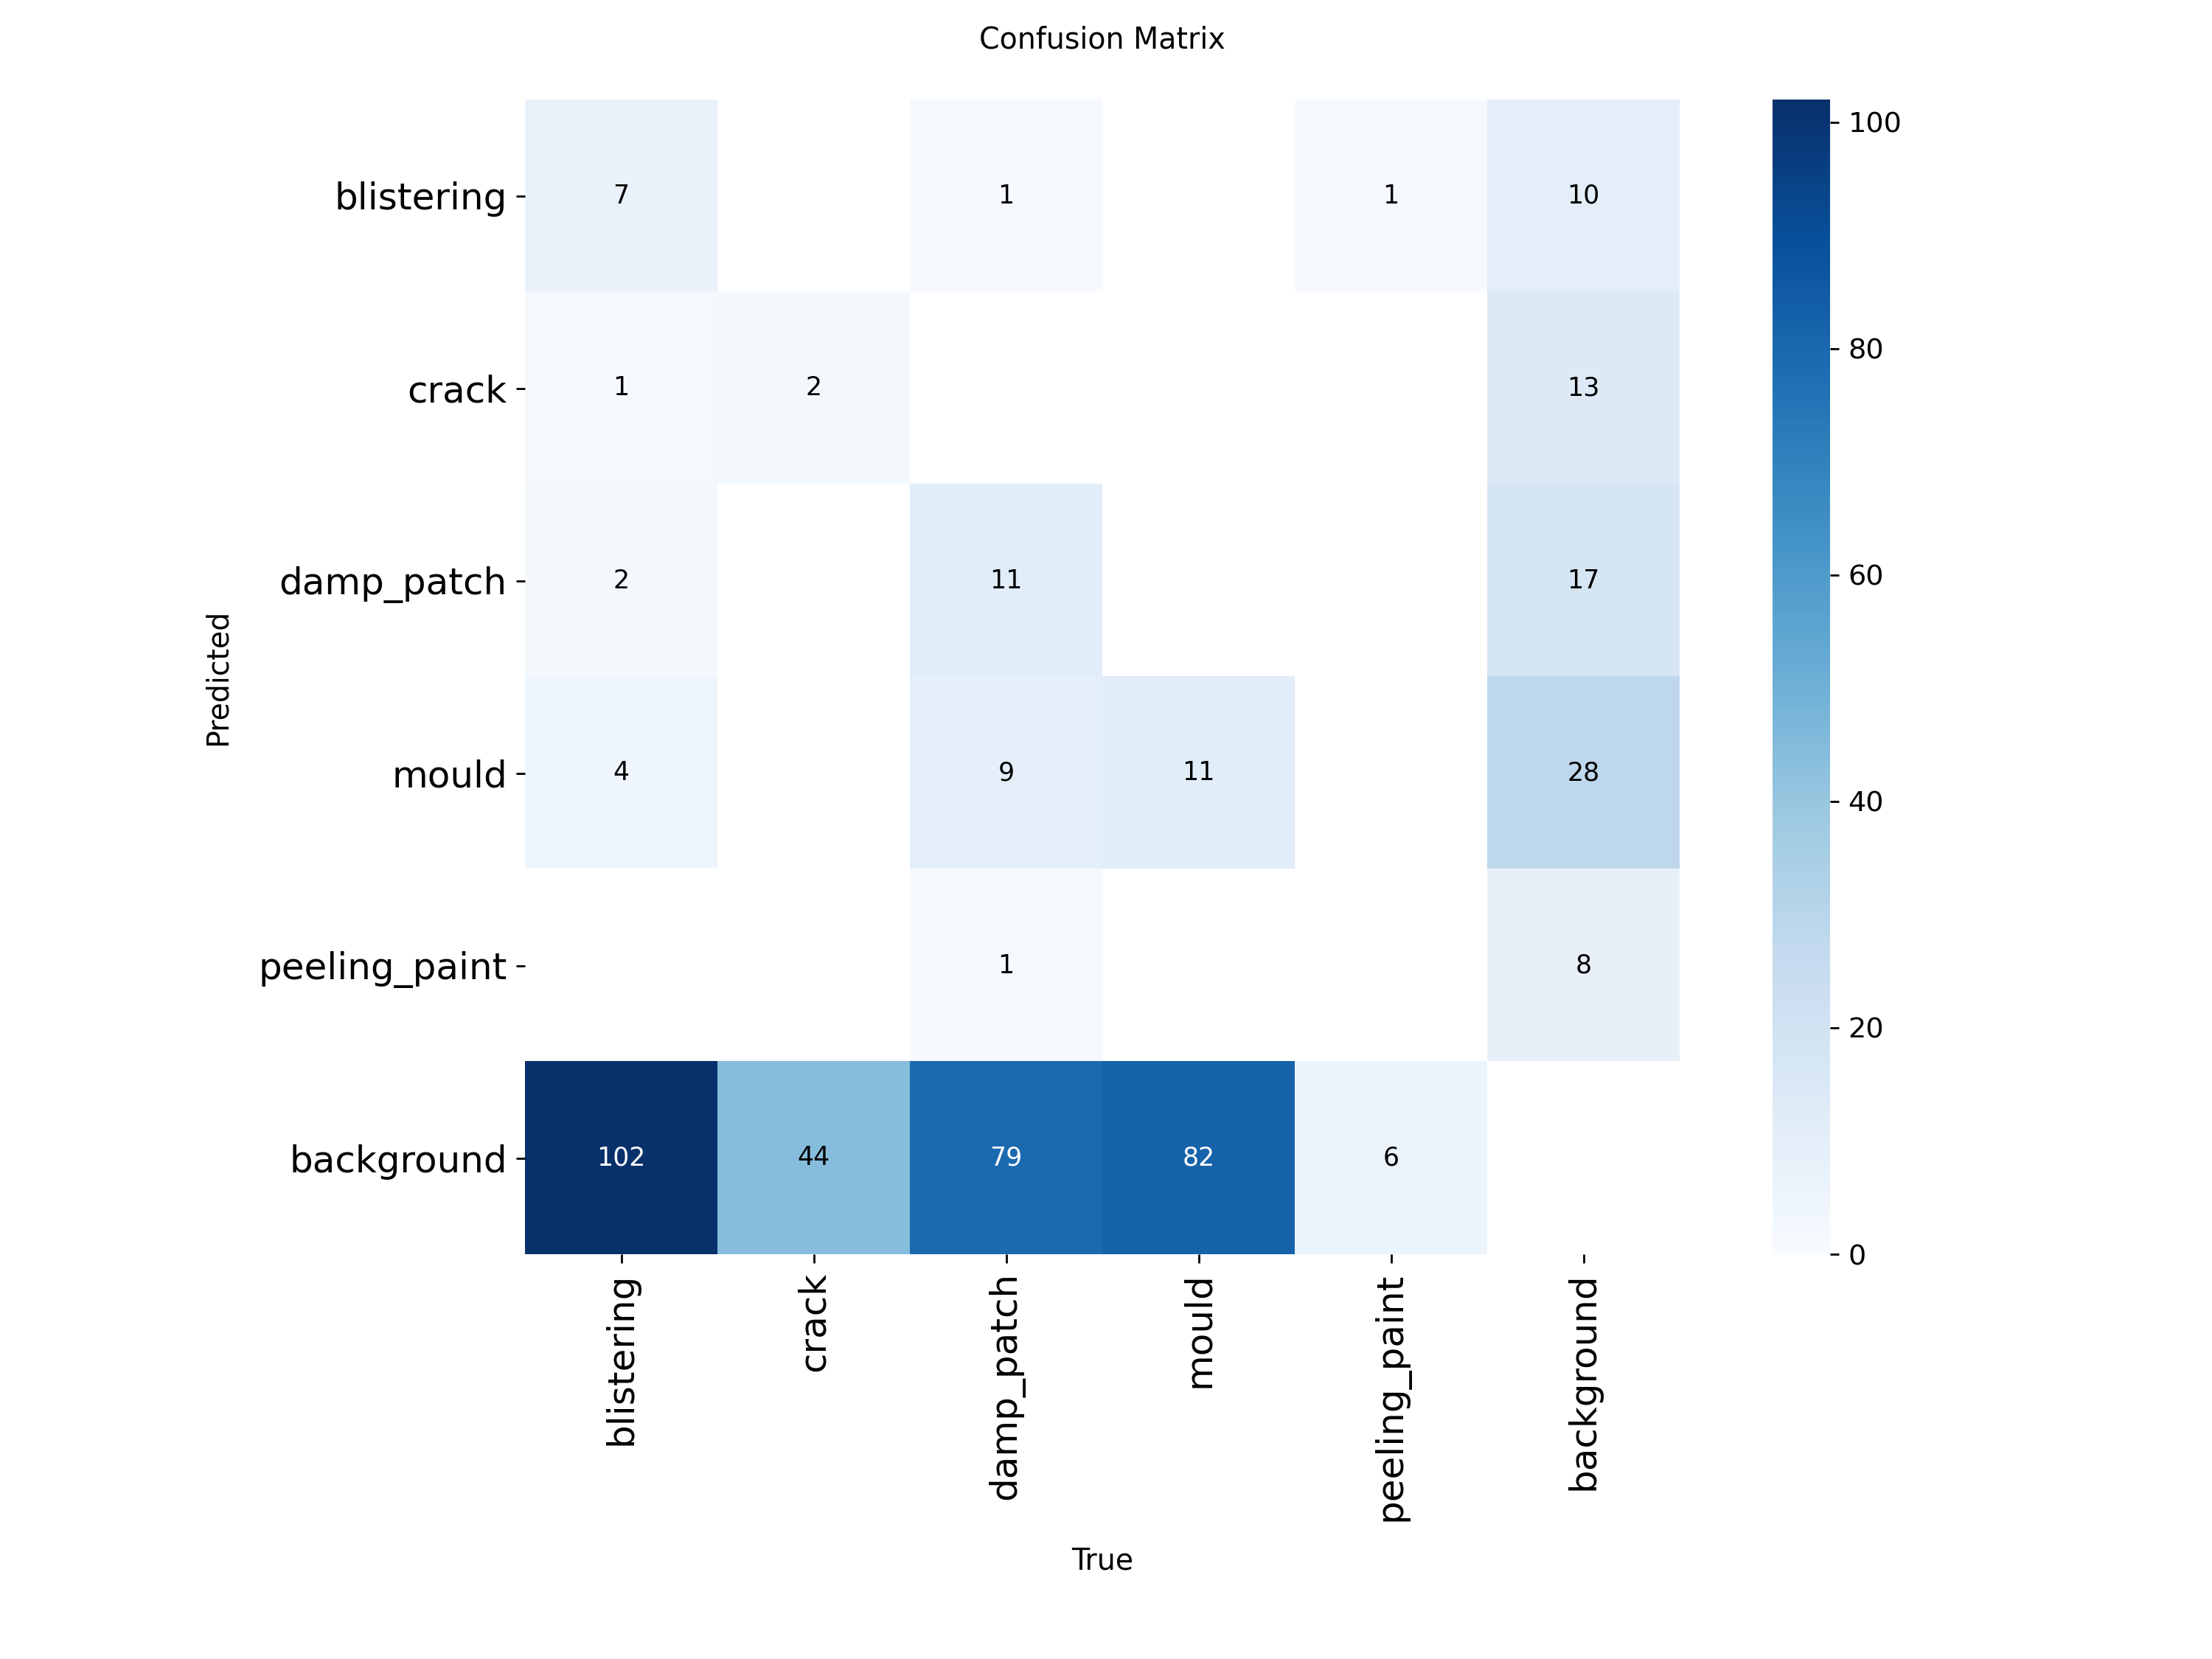

(missing: PR_curve.png)
(missing: R_curve.png)
(missing: P_curve.png)
(missing: F1_curve.png)

=== labels.jpg ===


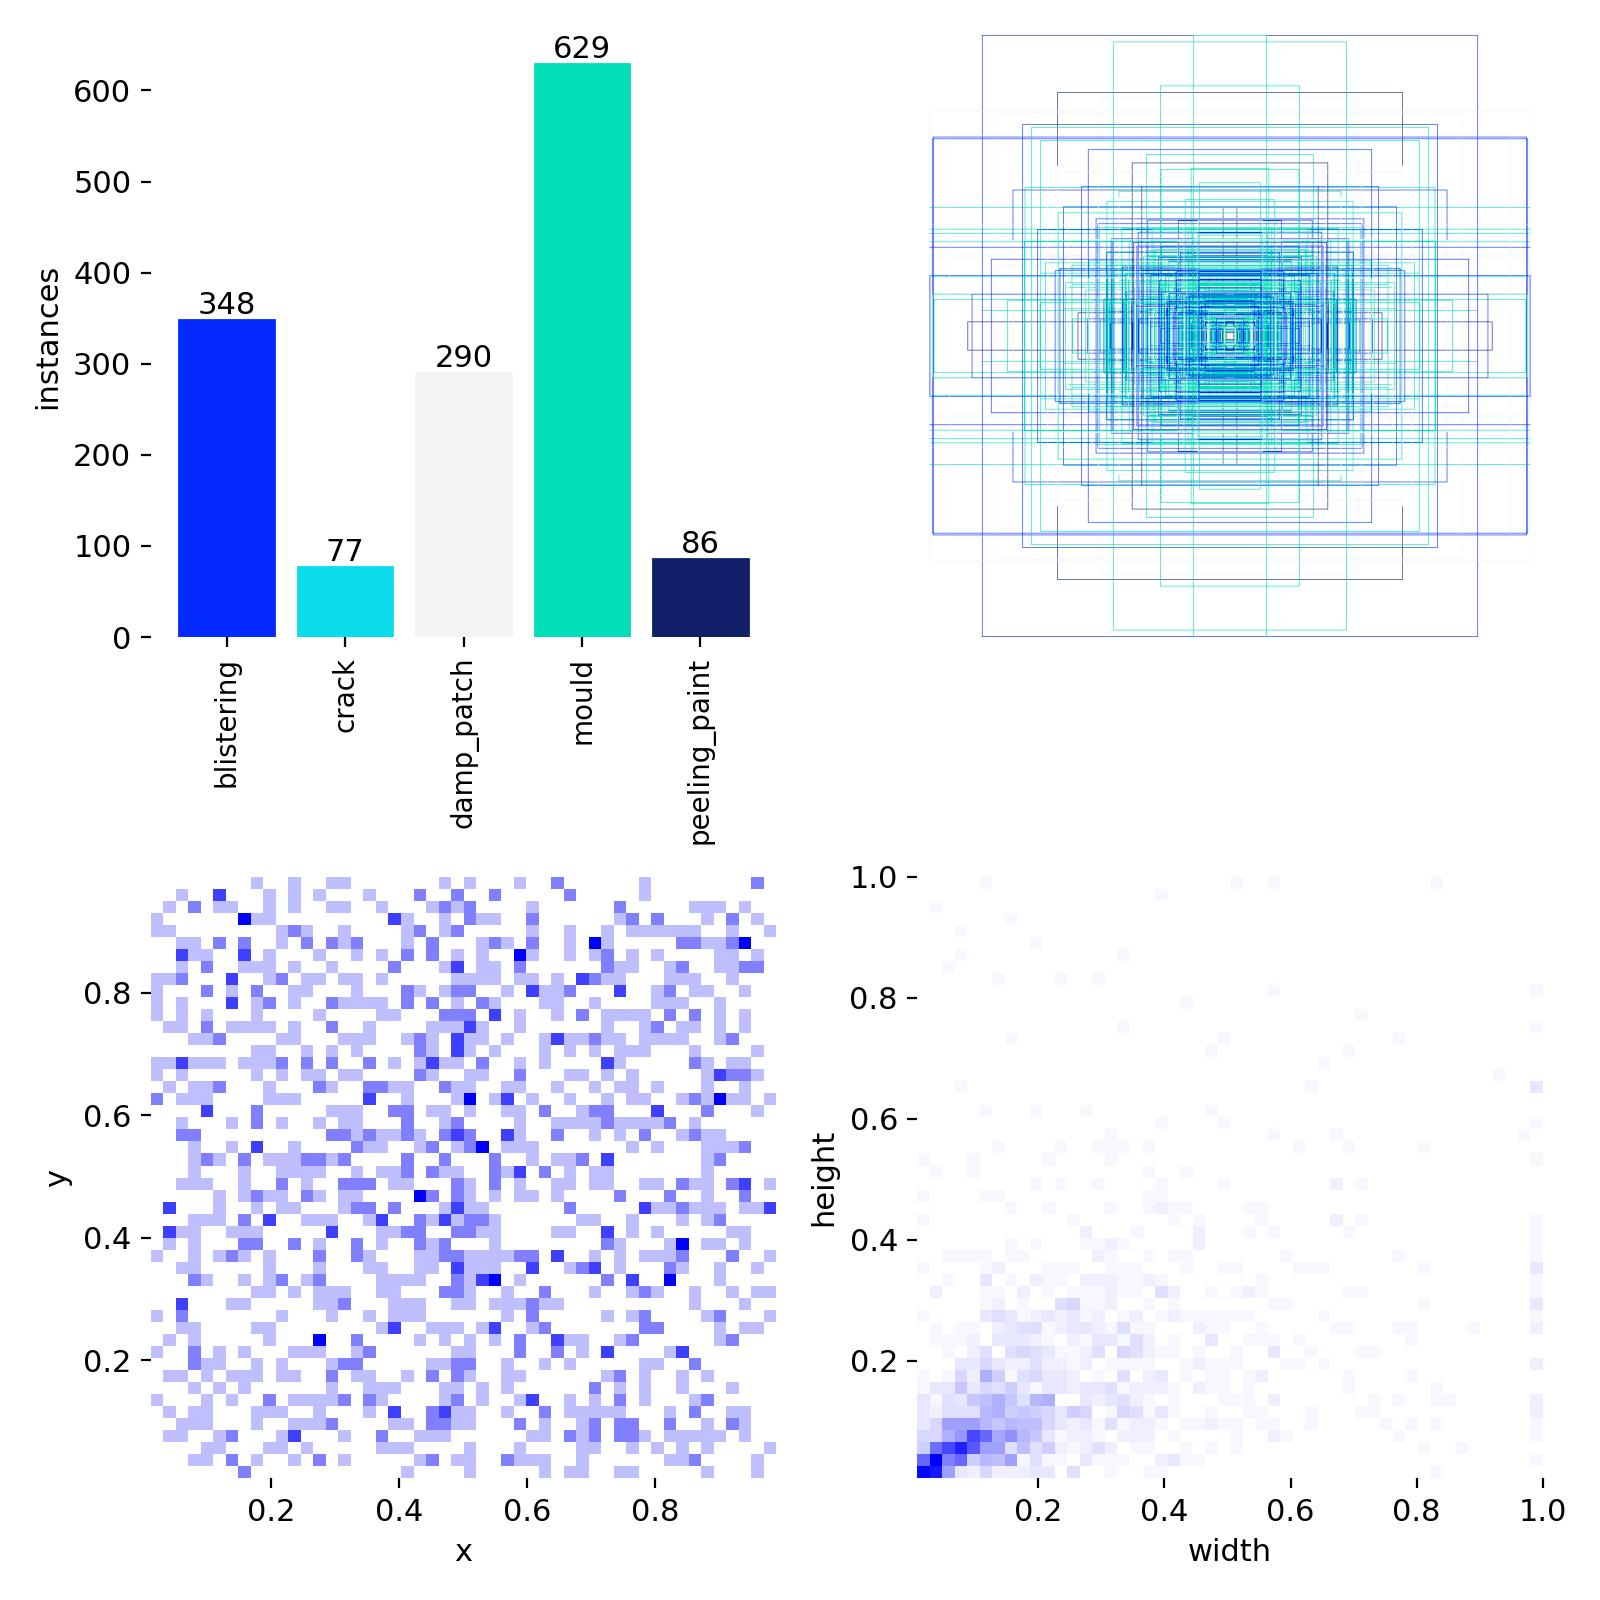


=== val_batch0_pred.jpg ===


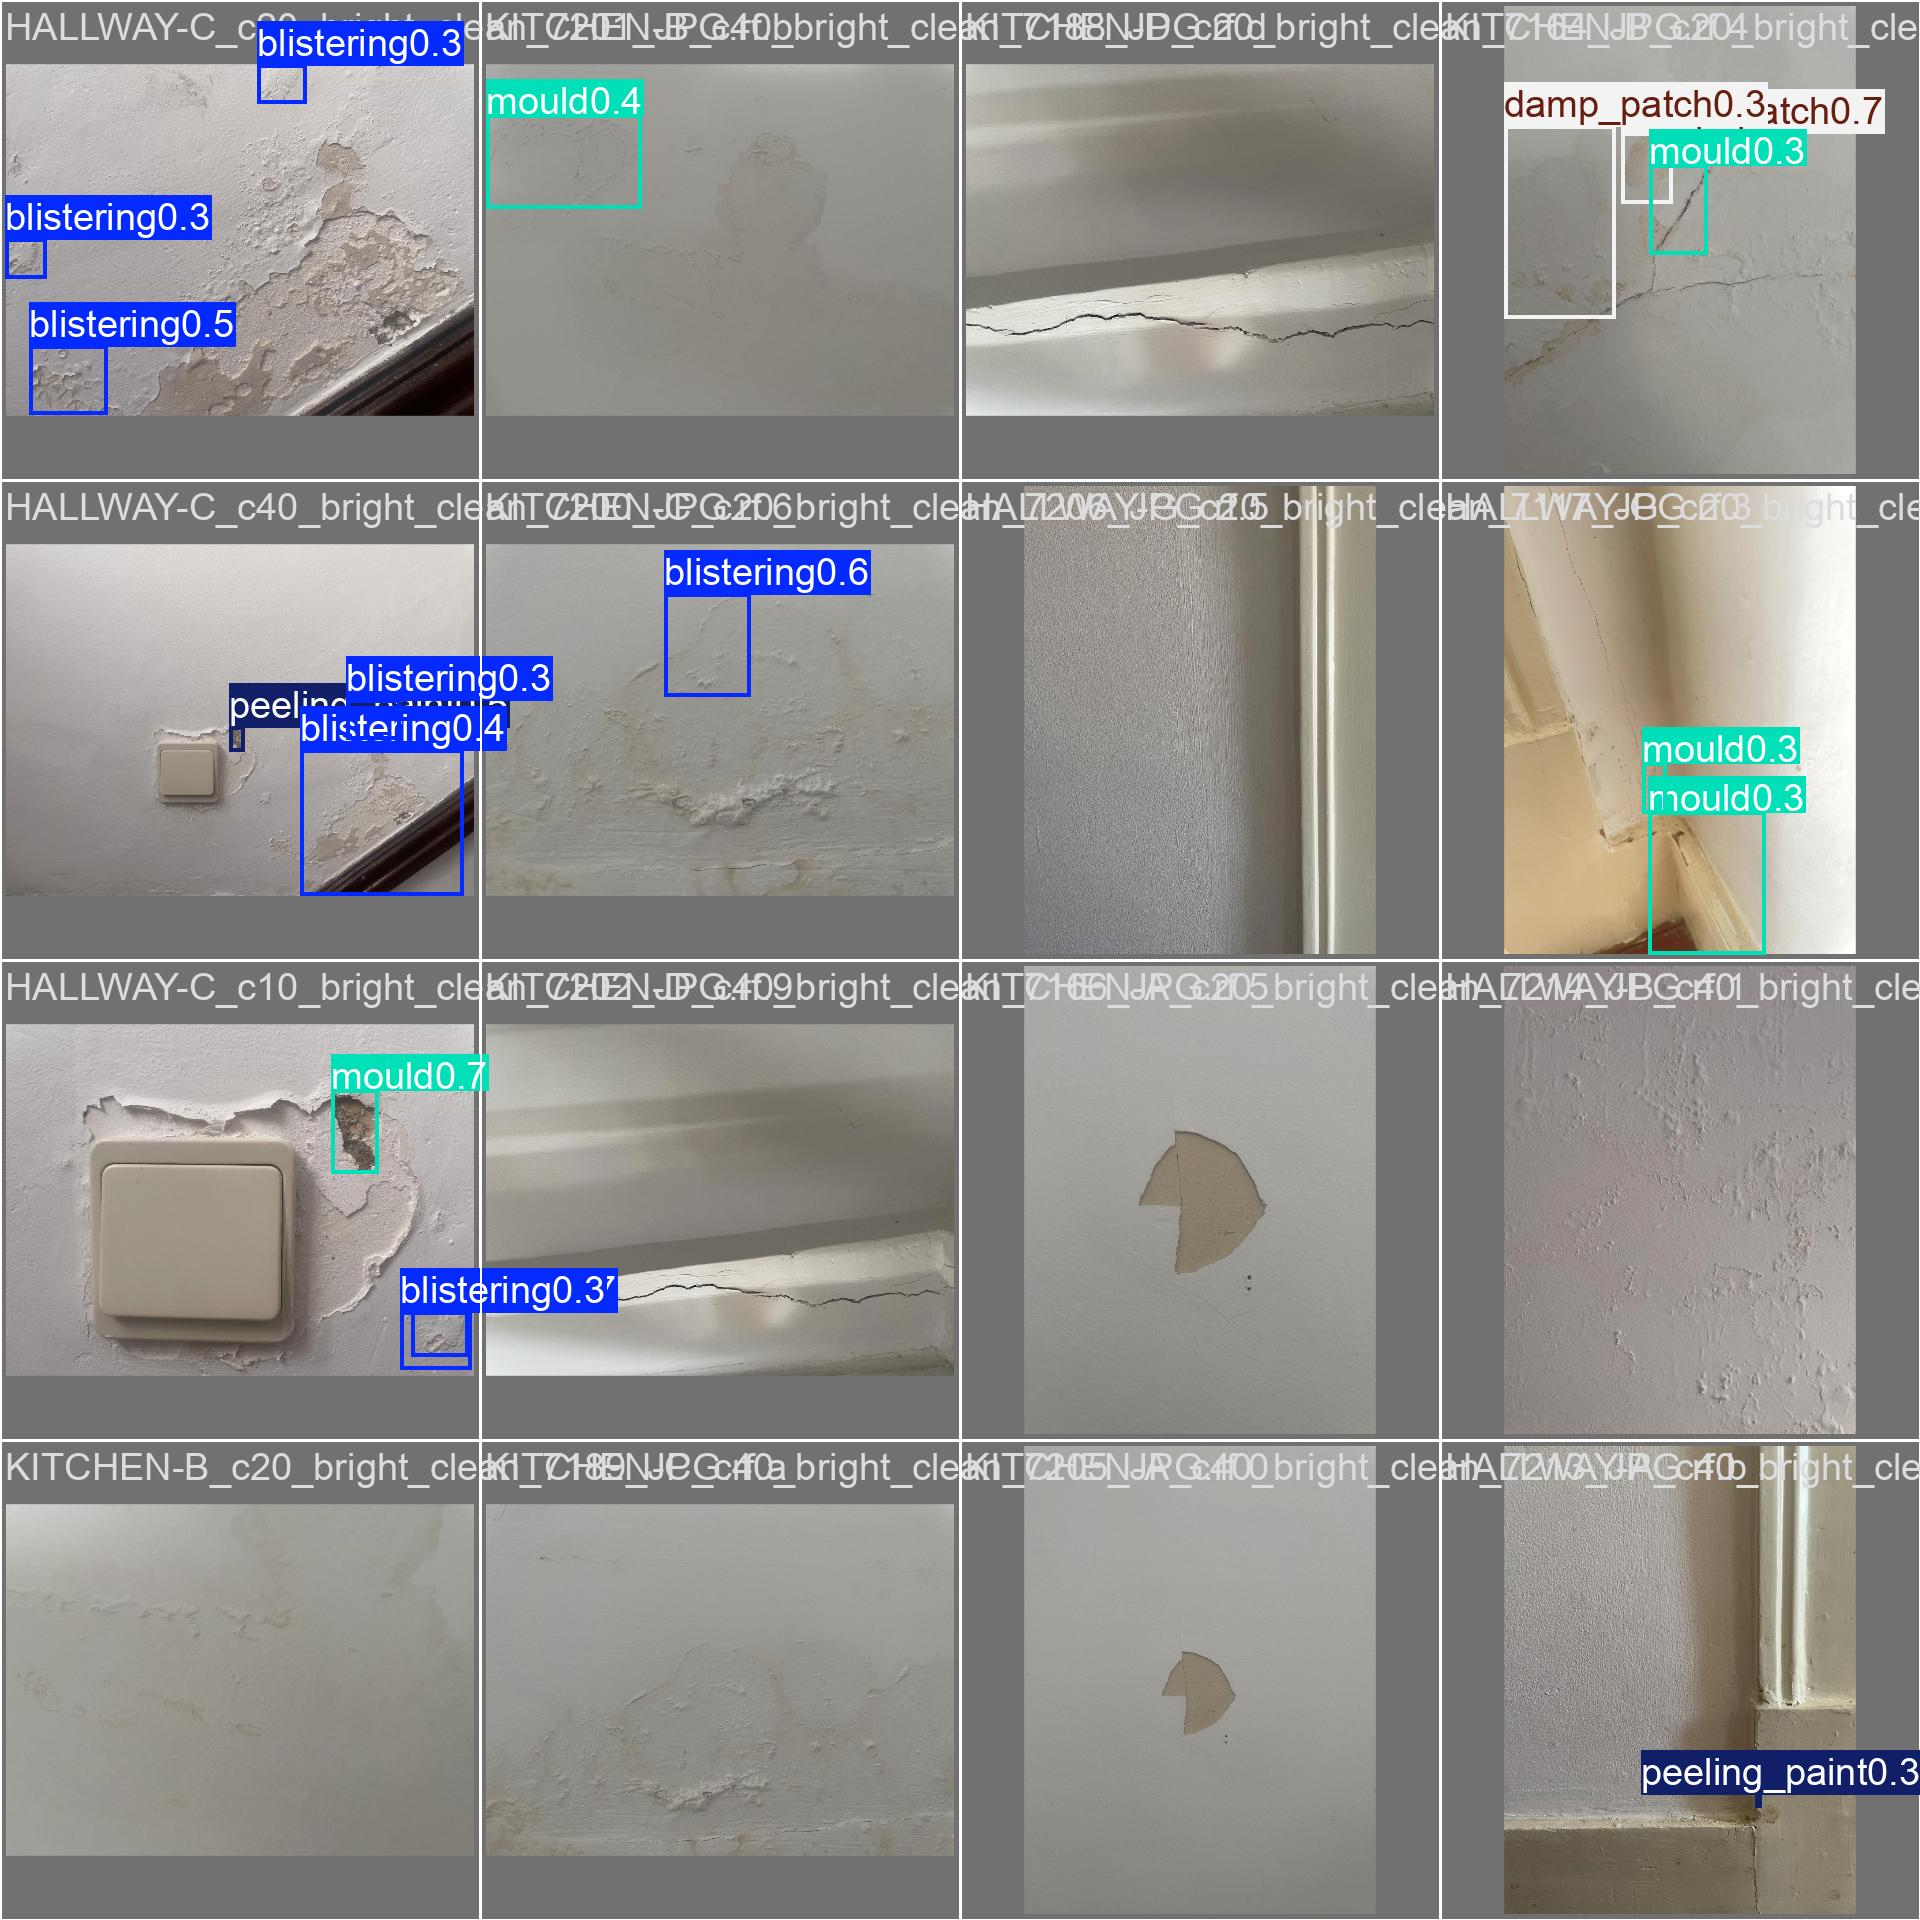

In [ ]:
from IPython.display import Image as IPyImage, display as ipy_display

FIXED = ["results.png", "confusion_matrix_normalized.png", "confusion_matrix.png",
         "labels.jpg", "results.csv", "args.yaml"]
CURVES = sorted(p.name for p in SAVE_DIR.glob("*[Cc]urve*.png"))

for fig in ["results.png", "confusion_matrix_normalized.png", "confusion_matrix.png",
            "PR_curve.png", "R_curve.png", "P_curve.png", "F1_curve.png",
            "labels.jpg", "val_batch0_pred.jpg"]:
    p = SAVE_DIR / fig
    if p.exists():
        print(f"\n=== {fig} ===")
        ipy_display(IPyImage(filename=str(p), width=900))
    else:
        print(f"(missing: {fig})")

**How to read these figures**

**`results.png`** — ten panels, top row training, bottom row validation.

The signal is the *relationship* between the train and val losses. Training losses falling smoothly means the model is learning the training set. What matters is the epoch at which `val/box_loss` and `val/dfl_loss` stop falling and turn upward while the training losses keep falling: that is the onset of overfitting, and the epoch it happens at is the number to quote.

Which validation loss diverges is diagnostic:

- `val/cls_loss` flat and low → the classification head generalises.
- `val/box_loss` and `val/dfl_loss` rising → the box-regression head does not.

`dfl_loss` is Distribution Focal Loss, which regresses **box edge positions** as a distribution.
It is, almost literally, the "where exactly does this thing stop" loss. In this project it is the one that diverges, which is the measurable trace of an annotation problem: the amorphous classes have no crisp boundary, so the network memorised the training set's boundary choices and they did not transfer.

**`confusion_matrix_normalized.png`** — note the axes carefully, they are easy to read backwards:

- the **y-axis (rows) is `Predicted`**
- the **x-axis (columns) is `True`**
- values are normalised down each **column**, so each column sums to 1

Therefore:

- the **`background` ROW = false negatives** — real defects for which the model produced no prediction matching at IoU ≥ 0.45. In run 2 this row reads 0.88 / 0.96 / 0.78 / 0.88 / 0.86, meaning 78–96% of annotated instances were missed. This is where nearly all the lost performance sits.
- the **`background` COLUMN = false positives** — predictions matching no ground truth. It is normalised over that column, so it shows the *composition* of the false positives, not their absolute number.
- **off-diagonal class-to-class cells = class confusion.** The largest normalised cells in run 2 are true `peeling_paint` → predicted `blistering` (0.14) and true `damp_patch` → predicted `mould` (0.09). Read these against absolute counts before drawing conclusions: the box-level accounting in `docs/error_analysis.md` §5.3 shows the first is **one instance** — 0.14 of seven validation instances — while the second is **eleven**. Column normalisation makes a single misclassification on a thin class look like a systematic failure.

A useful check: in run 1 the `peeling_paint` → `blistering` cell was empty, not because the classes were separable but because the model detected almost nothing. A misclassification cannot be observed if nothing is classified.

> **Note on missing curve files.** Recent Ultralytics versions prefix the detection curve
> files with `Box` — `BoxPR_curve.png`, `BoxF1_curve.png` and so on. If a figure reports as
> missing, that is usually the filename, not a failed plot. See the code fix below.

---


## **9. Evaluate — validation, then test**

Two evaluations, reported separately, because they answer different questions.

**Validation** selected `best.pt` and drove early stopping. Its figures are mildly optimistic by construction — the checkpoint was chosen *because* it scored well here.

**Test** was touched once, now. In principle it is the unbiased number.

In practice it is not usable per class. The audit in #6 measured 46 test images, 23 of them background, and 73 instances across five classes — `damp_patch` 12, `peeling_paint` 7. Per-class figures on that support are noise.

The README therefore reports **validation as the primary table**, with the test table alongside and its support stated next to every figure — rather than quoting whichever number is higher.
Rebuilding the test split into something measurable is data improvement (2) in
`docs/error_analysis.md` section #6.


In [ ]:
best = YOLO(str(BEST))

def metric_table(metrics, label):
    rows = []
    names = metrics.names
    idx = getattr(metrics.box, "ap_class_index", None)
    if idx is None:
        idx = metrics.ap_class_index
    for i, ci in enumerate(idx):
        p, r, ap50, ap = metrics.box.class_result(i)
        rows.append({"class": names[ci], "precision": p, "recall": r,
                     "mAP50": ap50, "mAP50-95": ap})
    rows.append({"class": "ALL (mean)",
                 "precision": metrics.box.mp, "recall": metrics.box.mr,
                 "mAP50": metrics.box.map50, "mAP50-95": metrics.box.map})
    df = pd.DataFrame(rows).set_index("class").round(4)
    print(f"\n{label}")
    display(df)
    return df

val_metrics = best.val(data=str(YAML_PATH), split="val", imgsz=IMGSZ,
                       project=str(ROOT / "runs"), name=f"{RUN_NAME}_val", exist_ok=True)
val_df = metric_table(val_metrics, "VALIDATION — used for checkpoint selection (optimistic)")
val_df.to_csv(EVIDENCE / "metrics_val.csv")

Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2836.2±706.3 MB/s, size: 126.9 KB)
val: Scanning /content/dataset/valid/labels.cache... 44 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 14.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5s/it 4.5s
                   all         44        363      0.145      0.139     0.0859     0.0332
            blistering         35        116      0.236      0.147      0.107     0.0429
                 crack         24         46     0.0437      0.087     0.0395     0.0125
            damp_patch         29        101      0.298      0.248      0.153     0.0519
                 mould         22         93      0.149      0.215      0.127     0.0566
         peeling_paint          5          7    

,precision,recall,mAP50,mAP50-95
class,,,,
blistering,0.2360,0.1466,0.1067,0.0429
crack,0.0437,0.0870,0.0395,0.0125
damp_patch,0.2979,0.2475,0.1525,0.0519
mould,0.1486,0.2151,0.1271,0.0566
peeling_paint,0.0000,0.0000,0.0035,0.0020
ALL (mean),0.1452,0.1392,0.0859,0.0332


**Validation results — the checkpoint-selection split**

`best.pt` is the checkpoint Ultralytics kept because it scored highest on **fitness**, which is`0.1 × mAP50 + 0.9 × mAP50-95`, not validation loss. Worth knowing, because it explains why the best epoch does not coincide with the `val/box_loss` minimum: two different criteria, measured on the same split.

That also makes these figures mildly optimistic. The checkpoint was chosen for scoring well here, so reporting them as the model's performance is reporting a maximum, not an expectation.

Per-class behaviour is as the dataset predicts: strongest on `damp_patch` and `mould`, the two classes with the most instances and the largest visual footprint; weak on `crack`, which has 77 training instances and features around 1 px wide at this resolution; and effectively unmeasurable on `peeling_paint`, which has **7 validation instances**.

That last point needs stating precisely. `peeling_paint` scoring 0.0 precision and 0.0 recall is not evidence that the model fails on the class. It is evidence that the validation split cannot measure the class. The distinction is the difference between reporting numbers and reading them.


In [ ]:
if "test" in split_dirs:
    test_metrics = best.val(data=str(YAML_PATH), split="test", imgsz=IMGSZ,
                            project=str(ROOT / "runs"), name=f"{RUN_NAME}_test", exist_ok=True)
    test_df = metric_table(test_metrics, "TEST — held out, evaluated once")
    test_df.to_csv(EVIDENCE / "metrics_test.csv")

    print("\nPer-class test support (frames containing the class):")
    display(audit_df.loc[["test"], CLASSES].T.rename(columns={"test": "instances"}))
    print("Classes with fewer than ~10 test instances: treat the figure as indicative only.")
else:
    print("no test split in the export")

Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1373.1±384.4 MB/s, size: 95.0 KB)
val: Scanning /content/dataset/test/labels... 46 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 1.8Kit/s 0.0s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.6s/it 4.7s
                   all         46         73     0.0243     0.0284     0.0134    0.00325
            blistering          7         12          0          0      0.013    0.00353
                 crack         15         25          0          0    0.00565   0.000967
            damp_patch          4         12     0.0647     0.0833     0.0333    0.00726
                 mould          4         17     0.0567     0.0588     0.0124    0.002

,precision,recall,mAP50,mAP50-95
class,,,,
blistering,0.0000,0.0000,0.0130,0.0035
crack,0.0000,0.0000,0.0056,0.0010
damp_patch,0.0647,0.0833,0.0333,0.0073
mould,0.0567,0.0588,0.0124,0.0026
peeling_paint,0.0000,0.0000,0.0029,0.0019
ALL (mean),0.0243,0.0284,0.0134,0.0032



Per-class test support (frames containing the class):


split,instances
blistering,12
crack,25
damp_patch,12
mould,17
peeling_paint,7


Classes with fewer than ~10 test instances: treat the figure as indicative only.


**Test results — the once-only evaluation**

The test split was never used during training, so unlike validation these figures carry no selection bias.

They are still not a reliable estimate of generalisation. 73 instances across five classes, with half the frames being deliberate hard negatives, is too little support for a per-class figure and thin even in aggregate. What the split *can* legitimately show is direction — and the gap between the validation and test tables is itself a finding, since it is dominated by the room-level domain shift described in #6.

For reporting: validation primary, test alongside, support stated beside every per-class number, and no selection of whichever table reads better.

---


## **10. Collect the evidence pack**

Everything the report and README need, gathered into one folder and zipped, plus a `run_record.json` generated from the same objects the trainer was given, so the provenance file cannot disagree with what actually ran.

It also records whether `close_mosaic` engaged before early stopping, and prints a warning if it did not. That limitation is measured by the code rather than inferred from a chart.


In [ ]:
import json as _json

# --- everything Ultralytics wrote: figures, curves, batch previews, logs --------
# Globbed rather than listed. A curated filename list silently drops anything
# Ultralytics renames or adds - which is exactly how PR_curve.png went missing
# when 8.4 started prefixing detection curves with "Box".
for pattern in ("*.png", "*.jpg", "*.csv", "*.yaml"):
    for src in sorted(SAVE_DIR.glob(pattern)):
        shutil.copy2(src, EVIDENCE / src.name)

# --- weights --------------------------------------------------------------------
shutil.copy2(BEST, EVIDENCE / "best.pt")

# --- provenance: generated from the same objects the trainer was given ----------
run_record = {
    "run_tag": RUN_TAG,
    "dataset_url": DATASET_URL,
    "dataset_sha256": DATASET_SHA256.lower(),
    "dataset_version": DATASET_VERSION,
    "n_classes": RUN["classes"],
    "classes": CLASSES,
    "model_weights": MODEL_WEIGHTS,
    "imgsz": IMGSZ,
    "batch": BATCH,
    "seed": SEED,
    "epochs_requested": RUN["epochs"],
    "patience": RUN["patience"],
    "augmentation": RUN["aug"],
    "ultralytics_version": ultralytics.__version__,
    "torch_version": torch.__version__,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "val_mAP50": float(val_metrics.box.map50),
    "val_mAP50_95": float(val_metrics.box.map),
}

if "test" in split_dirs:
    run_record["test_mAP50"] = float(test_metrics.box.map50)
    run_record["test_mAP50_95"] = float(test_metrics.box.map)

# --- did close_mosaic actually engage? ------------------------------------------
# epochs=150 with close_mosaic=30 switches mosaic off at epoch 120. Early stopping
# can end the run before that, in which case the mosaic-free finishing phase never
# happened. Recorded rather than assumed — see docs/error_analysis.md §4.5.
rcsv = SAVE_DIR / "results.csv"
if rcsv.exists():
    epochs_trained = sum(1 for line in rcsv.read_text().splitlines() if line.strip()) - 1
    run_record["epochs_trained"] = epochs_trained
    cm = RUN["aug"].get("close_mosaic")
    if cm is not None:
        run_record["close_mosaic_off_at_epoch"] = RUN["epochs"] - cm
        run_record["close_mosaic_engaged"] = epochs_trained > (RUN["epochs"] - cm)

(EVIDENCE / "run_record.json").write_text(_json.dumps(run_record, indent=2))
print(_json.dumps(run_record, indent=2))

if run_record.get("close_mosaic_engaged") is False:
    print("\n!! close_mosaic never engaged: training stopped at epoch "
          f"{run_record['epochs_trained']}, mosaic would have switched off at "
          f"{run_record['close_mosaic_off_at_epoch']}.")
    print("   Every metric above comes from a model trained entirely under mosaic.")

# --- zip the pack ----------------------------------------------------------------
shutil.make_archive(str(ROOT / f"evidence_{RUN_TAG}"), "zip", EVIDENCE)
print(f"\nwrote {ROOT / f'evidence_{RUN_TAG}.zip'}")
print("\nfiles:")
for p in sorted(EVIDENCE.iterdir()):
    print(f"  {p.name:<40}{p.stat().st_size/1024:>8.0f} KB")


{
  "run_tag": "run2",
  "dataset_url": "https://github.com/JBA69/interior-wall-defects/releases/download/v1.0/interior-wall-defects-v1-yolo11.zip",
  "dataset_sha256": "9137b89d2f406adf1fa7dbfc6bf5a2e95db396d39c26a8c80d248a2f0b8b8a42",
  "dataset_version": "v1",
  "n_classes": 5,
  "classes": [
    "blistering",
    "crack",
    "damp_patch",
    "mould",
    "peeling_paint"
  ],
  "model_weights": "yolo11s.pt",
  "imgsz": 1280,
  "batch": 8,
  "seed": 0,
  "epochs_requested": 150,
  "patience": 40,
  "augmentation": {
    "mosaic": 1.0,
    "close_mosaic": 30,
    "scale": 0.5,
    "hsv_v": 0.3,
    "hsv_s": 0.6,
    "hsv_h": 0.015,
    "degrees": 0.0,
    "flipud": 0.0,
    "fliplr": 0.5,
    "translate": 0.1,
    "erasing": 0.0
  },
  "ultralytics_version": "8.4.166",
  "torch_version": "2.11.0+cu128",
  "device": "Tesla T4",
  "val_mAP50": 0.0858564902988774,
  "val_mAP50_95": 0.03315301740043206,
  "test_mAP50": 0.013436769803145773,
  "test_mAP50_95": 0.003246989715272609,
  "ep

In [ ]:
pack = ROOT / f"evidence_{RUN_TAG}.zip"
assert pack.exists(), f"{pack} was not written — check the §10 cell output for an error."

try:
    from google.colab import files
    files.download(str(pack))
except Exception as e:
    print(f"(not in Colab, or download blocked: {e})")
    print(f"evidence pack is at {pack}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---


## **11. Results summary — paste into the README**

The cell below prints a markdown table. Copy it into `README.md` under **Results**. Do not
retype the numbers by hand.


In [ ]:
lines = []
lines.append(f"**Model:** YOLO11s · **Resolution:** {IMGSZ} · "
             f"**Dataset:** `{DATASET_VERSION}` (SHA256 `{DATASET_SHA256[:12]}…`)\n")
lines.append("**Validation** (used for checkpoint selection — mildly optimistic)\n")
lines.append(val_df.to_markdown())
if "test" in split_dirs:
    lines.append("\n**Test** (held out, evaluated once)\n")
    lines.append(test_df.to_markdown())
    lines.append("\n> The test split is small and unevenly distributed across classes "
                 "(see `evidence/dataset_audit.csv`). Per-class test figures for classes "
                 "with few instances are indicative, not reliable. Validation is reported "
                 "as the primary table for that reason, and the gap between the two tables "
                 "is itself a finding.")

summary = "\n".join(lines)
(EVIDENCE / "results_summary.md").write_text(summary)
print(summary)

**Model:** YOLO11s · **Resolution:** 1280 · **Dataset:** `v1` (SHA256 `9137b89d2f40…`)

**Validation** (used for checkpoint selection — mildly optimistic)

| class         |   precision |   recall |   mAP50 |   mAP50-95 |
|:--------------|------------:|---------:|--------:|-----------:|
| blistering    |      0.236  |   0.1466 |  0.1067 |     0.0429 |
| crack         |      0.0437 |   0.087  |  0.0395 |     0.0125 |
| damp_patch    |      0.2979 |   0.2475 |  0.1525 |     0.0519 |
| mould         |      0.1486 |   0.2151 |  0.1271 |     0.0566 |
| peeling_paint |      0      |   0      |  0.0035 |     0.002  |
| ALL (mean)    |      0.1452 |   0.1392 |  0.0859 |     0.0332 |

**Test** (held out, evaluated once)

| class         |   precision |   recall |   mAP50 |   mAP50-95 |
|:--------------|------------:|---------:|--------:|-----------:|
| blistering    |      0      |   0      |  0.013  |     0.0035 |
| crack         |      0      |   0      |  0.0056 |     0.001  |
| damp_patch  


## **Next**

`02_Inference.ipynb` — run `best.pt` over the test split and the 12 holdout frames that were never uploaded to Roboflow, and produce the annotated images for the error analysis.

**Screening, not certification.** This model indicates where a surveyor should look. It does not assess severity, depth, moisture content, or structural significance, and its output is not a condition report.

At the performance measured here it does not yet meet that bar either: missing 78–96% of annotated instances, it cannot be used to conclude that a wall is clear. It is reported as a baseline and a method, not as a deployable tool. The reasons, and what would change them, are in `docs/error_analysis.md`.
